# Uncertainty-Aware Colorization

Standard colorization models predict a single color per pixel, but colorization
is ill-posed: many colors are plausible for the same gray patch. This model
predicts **both** a color and a **confidence** for each pixel.

The architecture adds a lightweight uncertainty head (a single 1×1 conv) on top
of the pretrained generator. The head predicts log-variance per ab channel. The
reconstruction loss switches from L1 to Gaussian NLL:

```
L_nll = 0.5 * (log_var + (ab_pred - ab_gt)^2 * exp(-log_var))
```

This forces the model to be uncertain where it genuinely cannot predict the right
color (flat walls, metal, concrete), and confident where context is clear (sky,
grass, skin).

The uncertainty map is a direct output of the model — no extra inference needed.

**Training strategy**: load the pretrained baseline generator, freeze it for the
first few epochs so only the uncertainty head trains, then unfreeze everything
for fine-tuning.


In [ ]:
!pip install fastai>=2.7 scikit-image tqdm -q


In [ ]:
import os
import glob
import numpy as np
from PIL import Image
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from skimage.color import rgb2lab, lab2rgb

import torch
from torch import nn, optim
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

from fastai.vision.learner import create_body
from torchvision.models.resnet import resnet18
from fastai.vision.models.unet import DynamicUnet

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
SIZE = 256
BASELINE_CHECKPOINT_DIR  = "/content/drive/MyDrive/colorization_checkpoints"
UNCERTAINTY_CHECKPOINT_DIR = "/content/drive/MyDrive/colorization_checkpoints_uncertainty"
os.makedirs(UNCERTAINTY_CHECKPOINT_DIR, exist_ok=True)


## Model Definitions

In [ ]:
def build_res_unet(n_input=1, n_output=2, size=256):
    try:
        from torchvision.models import ResNet18_Weights
        model = resnet18(weights='DEFAULT')
    except:
        try:
            model = resnet18(pretrained=True)
        except:
            model = resnet18(pretrained=False)
            print("warning: no pretrained weights")

    if n_input == 1:
        old_conv = model.conv1
        with torch.no_grad():
            new_conv = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
            new_conv.weight.data = old_conv.weight.data.mean(dim=1, keepdim=True)
        model.conv1 = new_conv

    body = create_body(model, cut=-2)
    return DynamicUnet(body, n_output, (size, size)).to(device)


class UncertaintyGenerator(nn.Module):
    """
    Wraps the pretrained colorization generator and adds a 1x1 conv uncertainty head.
    Forward returns (ab_mean, log_var), both [B, 2, H, W].
    """
    def __init__(self, base_generator):
        super().__init__()
        self.base = base_generator
        self.logvar_head = nn.Conv2d(2, 2, kernel_size=1)
        nn.init.zeros_(self.logvar_head.weight)
        nn.init.constant_(self.logvar_head.bias, -2.0)  # start with low uncertainty

    def forward(self, L):
        ab_mean = self.base(L)
        log_var = self.logvar_head(ab_mean)
        return ab_mean, log_var


class PatchDiscriminator(nn.Module):
    def __init__(self, input_c, num_filters=64, n_down=3):
        super().__init__()
        self.model = self.get_layers(input_c, num_filters, n_down)

    def get_layers(self, input_c, num_filters, n_down):
        model = [self.get_conv(input_c, num_filters, norm=False)]
        for i in range(n_down):
            model += [self.get_conv(num_filters * 2**i, num_filters * 2**(i+1),
                                    stride=1 if i == (n_down - 1) else 2)]
        model += [self.get_conv(num_filters * 2**n_down, 1, stride=1, norm=False, act=False)]
        return nn.Sequential(*model)

    def get_conv(self, in_c, out_c, kernel_size=4, stride=2, padding=1, norm=True, act=True):
        layers = [nn.Conv2d(in_c, out_c, kernel_size, stride, padding, bias=not norm)]
        if norm: layers.append(nn.BatchNorm2d(out_c))
        if act:  layers.append(nn.LeakyReLU(0.2, True))
        return nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


class GANLoss(nn.Module):
    def __init__(self, real_label=1.0, fake_label=0.0):
        super().__init__()
        self.register_buffer('real_label', torch.tensor(real_label))
        self.register_buffer('fake_label', torch.tensor(fake_label))
        self.loss = nn.BCEWithLogitsLoss()
    def get_labels(self, preds, is_real):
        return (self.real_label if is_real else self.fake_label).expand_as(preds)
    def __call__(self, preds, is_real):
        return self.loss(preds, self.get_labels(preds, is_real))


def init_weights(net, gain=0.02):
    def fn(m):
        cn = m.__class__.__name__
        if hasattr(m, 'weight') and 'Conv' in cn:
            nn.init.normal_(m.weight.data, 0.0, gain)
            if hasattr(m, 'bias') and m.bias is not None:
                nn.init.constant_(m.bias.data, 0.0)
        elif 'BatchNorm2d' in cn:
            nn.init.normal_(m.weight.data, 1.0, gain)
            nn.init.constant_(m.bias.data, 0.0)
    net.apply(fn)
    return net

def init_model(model, device):
    return init_weights(model.to(device))

def total_variation_loss(img):
    return (torch.abs(img[:,:,:,:-1] - img[:,:,:,1:]).mean() +
            torch.abs(img[:,:,:-1,:] - img[:,:,1:,:]).mean())


class AverageMeter:
    def __init__(self):
        self.reset()
    def reset(self):
        self.count, self.avg, self.sum = [0.] * 3
    def update(self, val, count=1):
        self.count += count
        self.sum   += count * val
        self.avg    = self.sum / self.count


print("definitions loaded")


definitions loaded


## Gaussian NLL Loss

In [ ]:
def gaussian_nll_loss(ab_mean, log_var, ab_target):
    """
    Gaussian negative log-likelihood.
    The model is penalized for wrong predictions AND for dishonest uncertainty:
      - wrong prediction + low uncertainty  → large penalty
      - wrong prediction + high uncertainty → smaller penalty (but log_var term grows)
      - right prediction + high uncertainty → penalty from log_var (don't be overconfident)
    """
    log_var = torch.clamp(log_var, -10.0, 10.0)
    return (0.5 * (log_var + (ab_target - ab_mean) ** 2 * torch.exp(-log_var))).mean()


## Main Model

In [ ]:
class MainModel(nn.Module):
    def __init__(self, net_G, lr_G=2e-4, lr_D=2e-4, beta1=0.5, beta2=0.999,
                 lambda_recon=100., lambda_TV=1.0):
        super().__init__()
        self.device       = device
        self.lambda_recon = lambda_recon
        self.lambda_TV    = lambda_TV
        self.net_G = net_G.to(device)
        self.net_D = init_model(PatchDiscriminator(input_c=3, n_down=3, num_filters=64), device)
        self.GAN   = GANLoss().to(device)
        self.opt_G = optim.Adam(self.net_G.parameters(), lr=lr_G, betas=(beta1, beta2))
        self.opt_D = optim.Adam(self.net_D.parameters(), lr=lr_D, betas=(beta1, beta2))

    def set_requires_grad(self, m, v):
        for p in m.parameters():
            p.requires_grad = v

    def setup_input(self, data):
        self.L  = data['L'].to(device)
        self.ab = data['ab'].to(device)

    def forward(self):
        self.ab_mean, self.log_var = self.net_G(self.L)
        # uncertainty = sqrt(variance), averaged over a and b channels
        self.uncertainty = torch.sqrt(
            torch.exp(torch.clamp(self.log_var, -10, 10)).mean(dim=1, keepdim=True)
        )

    def backward_D(self):
        fake_img  = torch.cat([self.L, self.ab_mean.detach()], dim=1)
        real_img  = torch.cat([self.L, self.ab], dim=1)
        self.loss_D_fake = self.GAN(self.net_D(fake_img), False)
        self.loss_D_real = self.GAN(self.net_D(real_img), True)
        self.loss_D = (self.loss_D_fake + self.loss_D_real) * 0.5
        self.loss_D.backward()

    def backward_G(self):
        fake_img = torch.cat([self.L, self.ab_mean], dim=1)
        self.loss_G_GAN   = self.GAN(self.net_D(fake_img), True)
        self.loss_G_recon = gaussian_nll_loss(self.ab_mean, self.log_var, self.ab) * self.lambda_recon
        self.loss_G_TV    = total_variation_loss(fake_img) * self.lambda_TV
        self.loss_G = self.loss_G_GAN + self.loss_G_recon + self.loss_G_TV
        self.loss_G.backward()

    def optimize(self):
        self.forward()
        if not hasattr(self, 'loss_D_fake') or self.loss_D_fake.item() > 0.3:
            self.net_D.train(); self.set_requires_grad(self.net_D, True)
            self.opt_D.zero_grad(); self.backward_D(); self.opt_D.step()
        self.net_G.train(); self.set_requires_grad(self.net_D, False)
        self.opt_G.zero_grad(); self.backward_G(); self.opt_G.step()


## Dataset

In [ ]:
DATASET_PATH = "/content/drive/MyDrive/datasets/coco_subset_16000"
NUM_IMAGES   = 13000

class ColorizationDataset(Dataset):
    def __init__(self, paths, split='train'):
        self.paths = paths
        if split == 'train':
            self.transforms = transforms.Compose([
                transforms.Resize((256, 256), Image.BICUBIC),
                transforms.RandomHorizontalFlip(),
            ])
        else:
            self.transforms = transforms.Resize((256, 256), Image.BICUBIC)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        img_lab = rgb2lab(np.array(self.transforms(img))).astype("float32")
        img_lab = transforms.ToTensor()(img_lab)
        return {'L': img_lab[[0]] / 50. - 1., 'ab': img_lab[[1, 2]] / 110.}

    def __len__(self):
        return len(self.paths)

def make_dataloaders(paths, split='train', batch_size=16, n_workers=2):
    return DataLoader(ColorizationDataset(paths, split), batch_size=batch_size,
                      num_workers=n_workers, pin_memory=True, shuffle=(split=='train'))

image_extensions = ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']
paths = []
for ext in image_extensions:
    paths.extend(glob.glob(os.path.join(DATASET_PATH, ext)))
    paths.extend(glob.glob(os.path.join(DATASET_PATH, '**', ext), recursive=True))

if not paths:
    raise RuntimeError(f"no images found in {DATASET_PATH}")

np.random.seed(123)
if len(paths) > NUM_IMAGES:
    paths = np.random.choice(paths, NUM_IMAGES, replace=False)

rand_idxs   = np.random.permutation(len(paths))
train_paths = paths[rand_idxs[:int(len(paths) * 0.8)]]
val_paths   = paths[rand_idxs[int(len(paths) * 0.8):]]

train_dl = make_dataloaders(train_paths, 'train', batch_size=16, n_workers=2)
val_dl   = make_dataloaders(val_paths,   'val',   batch_size=16, n_workers=2)
print(f"train: {len(train_paths)}  val: {len(val_paths)}")


train: 10400  val: 2600


## Load Pretrained Generator + Build Uncertainty Model

In [ ]:
base_G = build_res_unet(n_input=1, n_output=2, size=SIZE)

pretrained_path = os.path.join(BASELINE_CHECKPOINT_DIR, "pretrained_generator.pth")
if os.path.exists(pretrained_path):
    base_G.load_state_dict(torch.load(pretrained_path, map_location=device))
    print(f"loaded pretrained generator from {pretrained_path}")
else:
    print(f"pretrained generator not found at {pretrained_path}")
    print("the uncertainty head can still train, but results will be weaker")

net_G = UncertaintyGenerator(base_G)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 140MB/s]


loaded pretrained generator from /content/drive/MyDrive/colorization_checkpoints/pretrained_generator.pth


## Training

Two-phase strategy:
1. **Phase 1 (5 epochs)**: freeze the base generator, train only the uncertainty head.
   The head learns to assign uncertainty to ambiguous regions without disturbing
   the pretrained color predictions.
2. **Phase 2 (15 epochs)**: unfreeze everything and fine-tune jointly.


In [ ]:
LAMBDA_RECON = 100.0
LAMBDA_TV    = 1.0
GAN_EPOCHS   = 20
DISPLAY_EVERY = 200

model = MainModel(net_G=net_G, lambda_recon=LAMBDA_RECON, lambda_TV=LAMBDA_TV)

# phase 1: freeze base, train only uncertainty head
PHASE1_EPOCHS = 5
print("phase 1: training uncertainty head only")
for p in model.net_G.base.parameters():
    p.requires_grad = False

val_data = next(iter(val_dl))

for e in range(PHASE1_EPOCHS):
    meters = {k: AverageMeter() for k in ['loss_D', 'loss_G_GAN', 'loss_G_recon', 'loss_G_TV', 'loss_G']}
    for data in tqdm(train_dl, desc=f"phase1 epoch {e+1}/{PHASE1_EPOCHS}"):
        model.setup_input(data)
        model.optimize()
        for k, m in meters.items():
            m.update(getattr(model, k).item(), data['L'].size(0))
    print(f"  epoch {e+1}  recon: {meters['loss_G_recon'].avg:.5f}  D: {meters['loss_D'].avg:.5f}")

# unfreeze for phase 2
for p in model.net_G.base.parameters():
    p.requires_grad = True
print("phase 2: fine-tuning full model")


phase 1: training uncertainty head only


phase1 epoch 1/5:   0%|          | 0/650 [00:00<?, ?it/s]

  epoch 1  recon: -98.56638  D: 0.61141


phase1 epoch 2/5:   0%|          | 0/650 [00:00<?, ?it/s]

  epoch 2  recon: -104.69022  D: 0.59152


...

  epoch 3  recon: -110.66650  D: 0.59152


phase1 epoch 4/5:   0%|          | 0/650 [00:00<?, ?it/s]

  epoch 4  recon: -116.44069  D: 0.59152


phase1 epoch 5/5:   0%|          | 0/650 [00:00<?, ?it/s]

  epoch 5  recon: -122.02139  D: 0.59152
phase 2: fine-tuning full model


In [ ]:
RESUME_TRAINING    = False
CHECKPOINT_TO_LOAD = "checkpoint_epoch_10.pth"
START_EPOCH        = 10

if RESUME_TRAINING:
    ckpt_path = os.path.join(UNCERTAINTY_CHECKPOINT_DIR, CHECKPOINT_TO_LOAD)
    if os.path.exists(ckpt_path):
        ckpt = torch.load(ckpt_path, map_location=device)
        model.net_G.load_state_dict(ckpt['generator_state_dict'])
        model.net_D.load_state_dict(ckpt['discriminator_state_dict'])
        model.opt_G.load_state_dict(ckpt['optimizer_G_state_dict'])
        model.opt_D.load_state_dict(ckpt['optimizer_D_state_dict'])
        print(f"resumed from epoch {ckpt['epoch']}")
    else:
        print(f"checkpoint not found: {ckpt_path}")
        RESUME_TRAINING = False


In [ ]:
loss_names = ['loss_D', 'loss_G_GAN', 'loss_G_recon', 'loss_G_TV', 'loss_G']

for e in range(START_EPOCH if RESUME_TRAINING else 0, GAN_EPOCHS):
    meters = {k: AverageMeter() for k in loss_names}
    unc_meter = AverageMeter()
    i = 0

    for data in tqdm(train_dl, desc=f"epoch {e+1}/{GAN_EPOCHS}"):
        model.setup_input(data)
        model.optimize()
        for k, m in meters.items():
            m.update(getattr(model, k).item(), data['L'].size(0))
        unc_meter.update(model.uncertainty.mean().item(), data['L'].size(0))
        i += 1

        if i % DISPLAY_EVERY == 0:
            print(f"\nepoch {e+1}  iter {i}/{len(train_dl)}")
            for k, m in meters.items():
                print(f"  {k}: {m.avg:.5f}")
            print(f"  mean_uncertainty: {unc_meter.avg:.4f}")

    if (e + 1) % 5 == 0 or (e + 1) == GAN_EPOCHS:
        ckpt_path = os.path.join(UNCERTAINTY_CHECKPOINT_DIR, f"checkpoint_epoch_{e+1}.pth")
        torch.save({
            'epoch': e + 1,
            'generator_state_dict':     model.net_G.state_dict(),
            'discriminator_state_dict': model.net_D.state_dict(),
            'optimizer_G_state_dict':   model.opt_G.state_dict(),
            'optimizer_D_state_dict':   model.opt_D.state_dict(),
        }, ckpt_path)
        print(f"  saved {ckpt_path}")

torch.save(model.net_G.state_dict(),
           os.path.join(UNCERTAINTY_CHECKPOINT_DIR, "uncertainty_generator.pth"))
print("done")


epoch 1/20:   0%|          | 0/650 [00:00<?, ?it/s]


epoch 1  iter 200/650
  loss_D: 0.59152
  loss_G_GAN: 0.85316
  loss_G_recon: -125.58009
  loss_G_TV: 0.05412
  loss_G: -124.67281
  mean_uncertainty: 0.2549

epoch 1  iter 400/650
  loss_D: 0.59152
  loss_G_GAN: 0.81700
  loss_G_recon: -126.64277
  loss_G_TV: 0.05449
  loss_G: -125.77128
  mean_uncertainty: 0.2518

epoch 1  iter 600/650
  loss_D: 0.59152
  loss_G_GAN: 0.79516
  loss_G_recon: -127.41086
  loss_G_TV: 0.05472
  loss_G: -126.56098
  mean_uncertainty: 0.2490


epoch 2/20:   0%|          | 0/650 [00:00<?, ?it/s]


epoch 2  iter 200/650
  loss_D: 0.59152
  loss_G_GAN: 0.77470
  loss_G_recon: -131.97905
  loss_G_TV: 0.05459
  loss_G: -131.14975
  mean_uncertainty: 0.2369

epoch 2  iter 400/650
  loss_D: 0.59152
  loss_G_GAN: 0.78543
  loss_G_recon: -132.60160
  loss_G_TV: 0.05495
  loss_G: -131.76122
  mean_uncertainty: 0.2345

epoch 2  iter 600/650
  loss_D: 0.59152
  loss_G_GAN: 0.78185
  loss_G_recon: -133.46525
  loss_G_TV: 0.05490
  loss_G: -132.62850
  mean_uncertainty: 0.2319


epoch 3/20:   0%|          | 0/650 [00:00<?, ?it/s]

...


epoch 18  iter 200/650
  loss_D: 0.59152
  loss_G_GAN: 0.85265
  loss_G_recon: -197.83627
  loss_G_TV: 0.05589
  loss_G: -196.92773
  mean_uncertainty: 0.0971

epoch 18  iter 400/650
  loss_D: 0.59152
  loss_G_GAN: 0.81897
  loss_G_recon: -197.53744
  loss_G_TV: 0.05622
  loss_G: -196.66226
  mean_uncertainty: 0.0964

epoch 18  iter 600/650
  loss_D: 0.59152
  loss_G_GAN: 0.82480
  loss_G_recon: -196.86062
  loss_G_TV: 0.05625
  loss_G: -195.97958
  mean_uncertainty: 0.0958


epoch 19/20:   0%|          | 0/650 [00:00<?, ?it/s]


epoch 19  iter 200/650
  loss_D: 0.59152
  loss_G_GAN: 0.87447
  loss_G_recon: -199.30942
  loss_G_TV: 0.05620
  loss_G: -198.37875
  mean_uncertainty: 0.0933

epoch 19  iter 400/650
  loss_D: 0.59152
  loss_G_GAN: 0.84349
  loss_G_recon: -199.63324
  loss_G_TV: 0.05628
  loss_G: -198.73346
  mean_uncertainty: 0.0927

epoch 19  iter 600/650
  loss_D: 0.59152
  loss_G_GAN: 0.82774
  loss_G_recon: -199.87369
  loss_G_TV: 0.05615
  loss_G: -198.98980
  mean_uncertainty: 0.0923


epoch 20/20:   0%|          | 0/650 [00:00<?, ?it/s]


epoch 20  iter 200/650
  loss_D: 0.59152
  loss_G_GAN: 0.76915
  loss_G_recon: -203.20949
  loss_G_TV: 0.05613
  loss_G: -202.38420
  mean_uncertainty: 0.0898

epoch 20  iter 400/650
  loss_D: 0.59152
  loss_G_GAN: 0.77594
  loss_G_recon: -202.41860
  loss_G_TV: 0.05637
  loss_G: -201.58629
  mean_uncertainty: 0.0893

epoch 20  iter 600/650
  loss_D: 0.59152
  loss_G_GAN: 0.78894
  loss_G_recon: -202.87637
  loss_G_TV: 0.05614
  loss_G: -202.03129
  mean_uncertainty: 0.0888
  saved /content/drive/MyDrive/colorization_checkpoints_uncertainty/checkpoint_epoch_20.pth
done


## Visualize Uncertainty Maps

/tmp/ipykernel_9956/2752852361.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


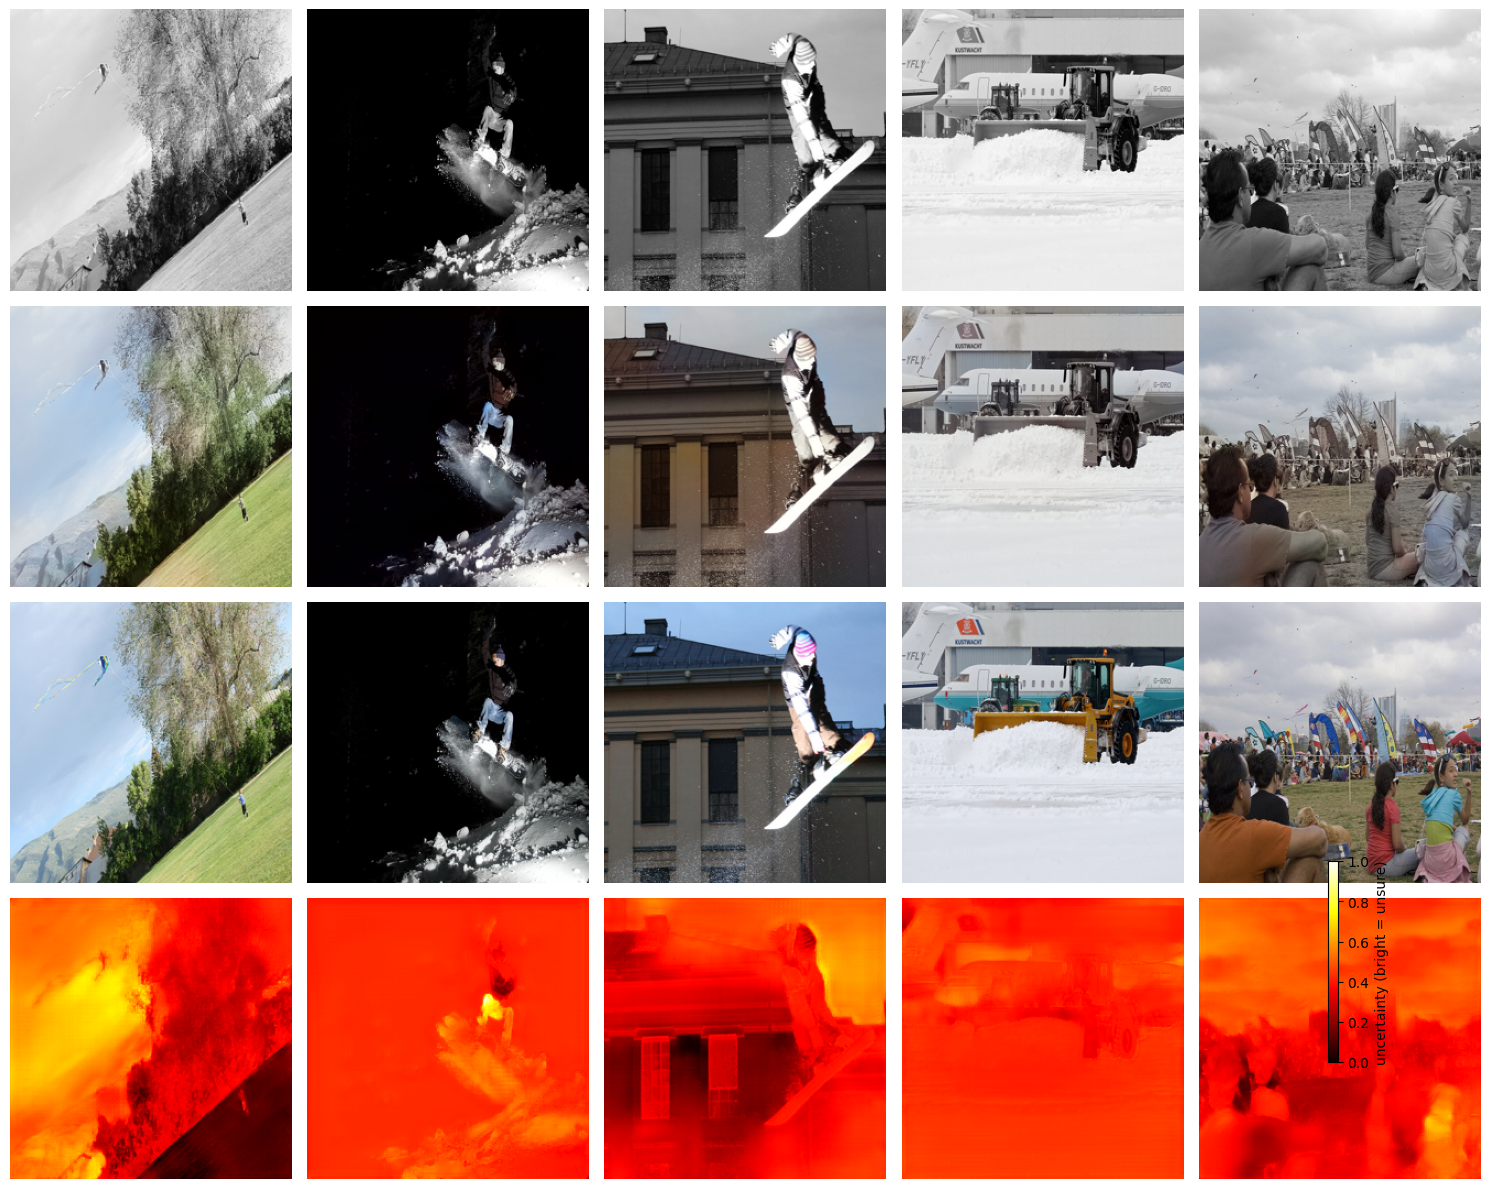

In [ ]:
def lab_to_rgb(L, ab):
    L  = (L + 1.) * 50.
    ab = ab * 110.
    Lab = torch.cat([L, ab], dim=1).permute(0, 2, 3, 1).cpu().numpy()
    return np.stack([lab2rgb(img) for img in Lab], axis=0)


def visualize_uncertainty(model, data, n=5, save=False, path="uncertainty.png"):
    model.net_G.eval()
    with torch.no_grad():
        model.setup_input(data)
        model.forward()
    model.net_G.train()

    n = min(n, len(model.L))
    colorized   = lab_to_rgb(model.L[:n], model.ab_mean[:n].detach())
    ground_truth = lab_to_rgb(model.L[:n], model.ab[:n])
    uncertainty = model.uncertainty[:n, 0].cpu().numpy()

    u_min, u_max = uncertainty.min(), uncertainty.max()
    unc_norm = (uncertainty - u_min) / (u_max - u_min + 1e-8)

    fig, axes = plt.subplots(4, n, figsize=(3 * n, 12))
    for i in range(n):
        axes[0, i].imshow(model.L[i][0].cpu(), cmap='gray');    axes[0, i].axis('off')
        axes[1, i].imshow(colorized[i]);                        axes[1, i].axis('off')
        axes[2, i].imshow(ground_truth[i]);                     axes[2, i].axis('off')
        im = axes[3, i].imshow(unc_norm[i], cmap='hot', vmin=0, vmax=1)
        axes[3, i].axis('off')

    axes[0, 0].set_ylabel("input",        fontsize=11)
    axes[1, 0].set_ylabel("colorized",    fontsize=11)
    axes[2, 0].set_ylabel("ground truth", fontsize=11)
    axes[3, 0].set_ylabel("uncertainty",  fontsize=11)

    fig.colorbar(im, ax=axes[3].tolist(), fraction=0.015, pad=0.01,
                 label="uncertainty (bright = unsure)")

    plt.tight_layout()
    if save:
        plt.savefig(path, bbox_inches='tight', dpi=120)
    plt.show()


visualize_uncertainty(model, next(iter(val_dl)), n=5, save=True,
                      path=os.path.join(UNCERTAINTY_CHECKPOINT_DIR, "uncertainty_final.png"))


## Uncertainty Histogram

Check that the model's uncertainty is not trivially uniform. We expect:
- Low uncertainty for semantically clear regions (sky, grass, skin)
- High uncertainty for ambiguous regions (concrete, metal, shadowed areas)


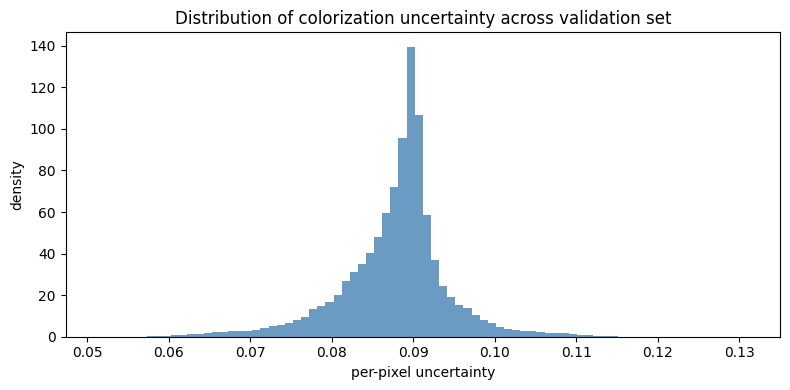

mean uncertainty: 0.0879
std  uncertainty: 0.0066


UncertaintyGenerator(
  (base): DynamicUnet(
    (layers): ModuleList(
      (0): Sequential(
        (0): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
        (4): Sequential(
          (0): BasicBlock(
            (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (relu): ReLU(inplace=True)
            (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          )
          (1): BasicBlock(
            (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), paddin

In [ ]:
model.net_G.eval()
all_unc = []
with torch.no_grad():
    for i, data in enumerate(val_dl):
        if i >= 20:
            break
        model.setup_input(data)
        model.forward()
        all_unc.append(model.uncertainty.cpu().numpy().ravel())

all_unc = np.concatenate(all_unc)

plt.figure(figsize=(8, 4))
plt.hist(all_unc, bins=80, density=True, color='steelblue', alpha=0.8)
plt.xlabel("per-pixel uncertainty")
plt.ylabel("density")
plt.title("Distribution of colorization uncertainty across validation set")
plt.tight_layout()
plt.savefig(os.path.join(UNCERTAINTY_CHECKPOINT_DIR, "uncertainty_histogram.png"),
            bbox_inches='tight', dpi=120)
plt.show()

print(f"mean uncertainty: {all_unc.mean():.4f}")
print(f"std  uncertainty: {all_unc.std():.4f}")
model.net_G.train()
